<a href="https://colab.research.google.com/github/sreehariar04/test_new/blob/main/CAR_PRICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***CAR PRICE PREDICTION APP***

## ***LOAD DATA***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import pickle


In [ ]:
car_data = pd.read_csv('/content/car_prediction_data.csv')
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
car_data.shape

(301, 9)

In [ ]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## ***DATA PREPROCESSING***

In [ ]:
car_data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
car_data.duplicated().sum()

np.int64(2)

In [ ]:
car_data.drop_duplicates(inplace=True)

In [ ]:
car_data.duplicated().sum()

np.int64(0)

In [ ]:
car_data.T.duplicated().sum()

np.int64(0)

### ***Outlier Detection and Handling***

In [ ]:
num_cols = car_data.select_dtypes(include=np.number).columns.tolist()
num_cols

['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

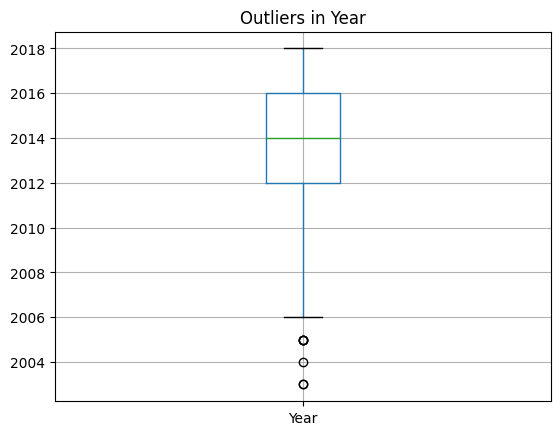

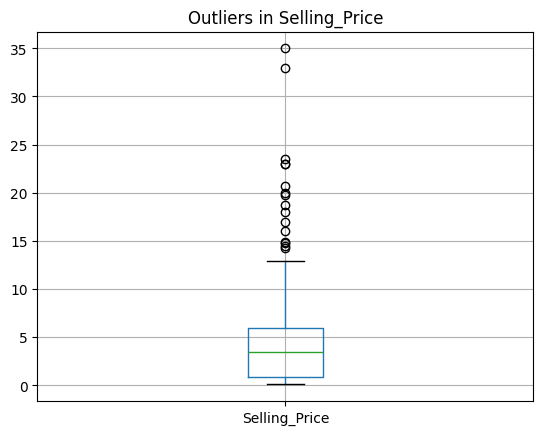

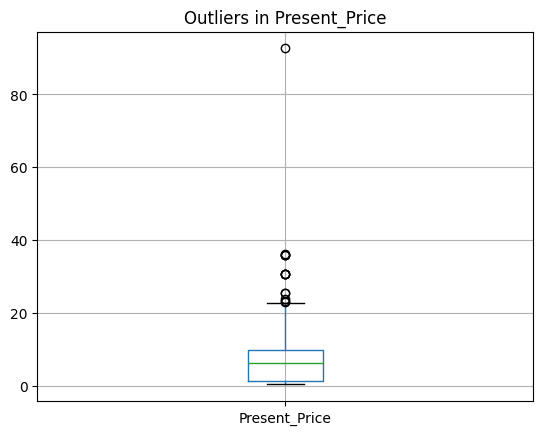

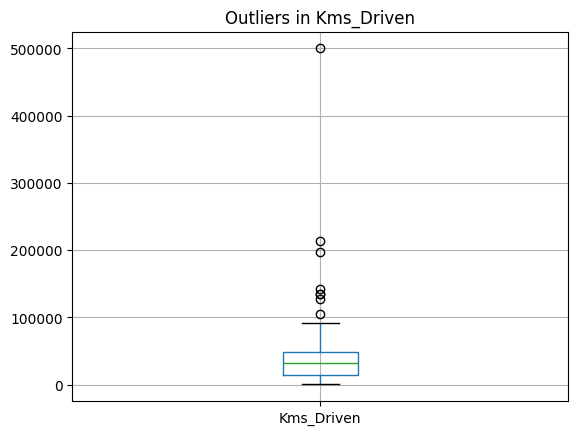

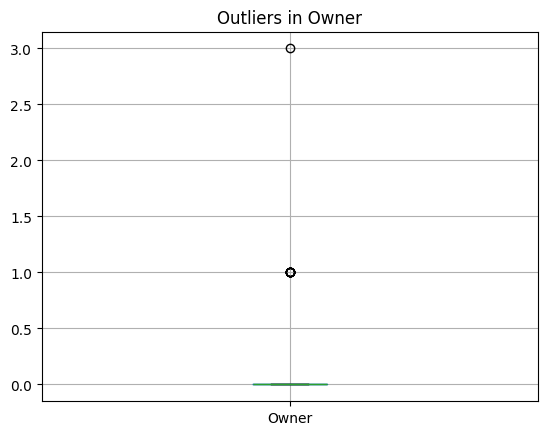

In [ ]:
for col in num_cols:
    plt.figure()
    car_data.boxplot(column=col)
    plt.title(f'Outliers in {col}')
    plt.show()


In [ ]:
print("Before:", car_data.shape)

Before: (299, 9)


In [ ]:

for col in num_cols:
    Q1 = car_data[col].quantile(0.25)
    Q3 = car_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    car_data = car_data[(car_data[col] >= lower) & (car_data[col] <= upper)]


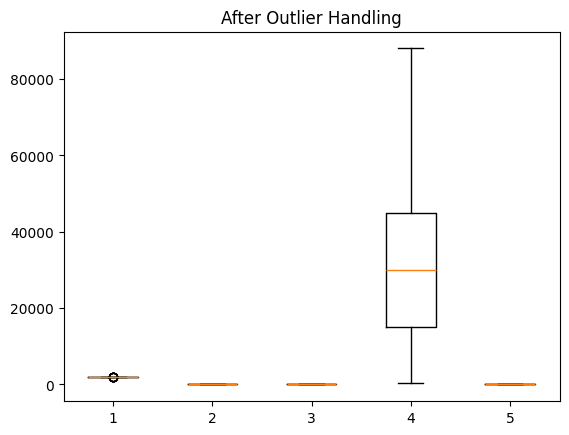

In [ ]:
plt.figure()
plt.boxplot(car_data[num_cols])
plt.title(('After Outlier Handling'))
plt.show()

In [ ]:
print("After:", car_data.shape)

After: (260, 9)


In [ ]:
car_data.nunique()

,0
Car_Name,89
Year,13
Selling_Price,134
Present_Price,128
Kms_Driven,188
Fuel_Type,3
Seller_Type,2
Transmission,2
Owner,1


### ***Feature Engineering***

### ***Encoding***

In [ ]:
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
num_cols = ['Present_Price', 'Kms_Driven', 'Year', 'Owner']


In [ ]:
name_encoder = LabelEncoder()
car_data['Car_Name'] = name_encoder.fit_transform(car_data['Car_Name'])

In [ ]:
car_data = pd.get_dummies(car_data, columns=cat_cols, drop_first=True)


In [ ]:
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,81,2014,3.35,5.59,27000,0,False,True,False,True
1,84,2013,4.75,9.54,43000,0,True,False,False,True
2,61,2017,7.25,9.85,6900,0,False,True,False,True
3,87,2011,2.85,4.15,5200,0,False,True,False,True
4,83,2014,4.60,6.87,42450,0,True,False,False,True


### ***Train-Test Split***

In [ ]:
X = car_data.drop('Selling_Price', axis=1)
y = car_data['Selling_Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
print(X.columns)


Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Owner',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual'],
      dtype='object')


### ***Scaling***

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ***Model Development***

### ***Linear Regression***

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))



R2 Score: 0.9095570611561864
MAE: 0.7177129235682705
MSE: 0.8947900308568675


In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print("Default RF R2:", rf.score(X_test, y_test))


Default RF R2: 0.955875846852257


## ***Hyper Parameter Tuning***

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

In [ ]:
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}
Best CV Score: 0.9332011522547431


In [ ]:
best_rf = random_search.best_estimator_


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_tuned = best_rf.predict(X_test)

print("Tuned RF R2:", r2_score(y_test, y_pred_tuned))
print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_tuned))


Tuned RF R2: 0.9458526123359234
Tuned RF MAE: 0.4243330860796969


In [ ]:
print("Linear Regression R2:", lr.score(X_test, y_test))
print("Default RF R2:", rf.score(X_test, y_test))
print("Tuned RF R2:", best_rf.score(X_test, y_test))


Linear Regression R2: 0.9095570611561864
Default RF R2: 0.955875846852257
Tuned RF R2: 0.9458526123359234


In [ ]:
if rf.score(X_test, y_test) > lr.score(X_test, y_test):
    print("Random Forest is the best model")
    best_model = rf
else:
    print("Linear Regression is the best model")
    best_model = lr


Random Forest is the best model


In [ ]:
import pickle
pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(name_encoder, open('name_encoder.pkl', 'wb'))
